### 🧠 Brain Tumor MRI Classification using Machine Learning

Objective: Develop an end-to-end machine learning pipeline that converts brain MRI images into numerical pixel features, performs preprocessing and dimensionality reduction using PCA, and classifies MRI scans into different brain tumor categories using Support Vector Machines (SVM).

**Tech Stack:** Python, OpenCV, Pandas, NumPy, Matplotlib, Scikit-learn

In [63]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
import os
import cv2

dataset_path = "archive"   

def create_csv(folder_path, output_csv):
    data = []

    for label in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, label)

        if not os.path.isdir(class_path):
            continue

        for image_name in sorted(os.listdir(class_path)):
            image_path = os.path.join(class_path, image_name)

            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            if image is None:
                continue

            image = cv2.resize(image, (128, 128))

            pixels = image.flatten().tolist()

            pixels.append(label)

            data.append(pixels)

    columns = [f"pixel{i}" for i in range(128 * 128)]
    columns.append("label")

    df = pd.DataFrame(data, columns=columns)

    df.to_csv(output_csv, index=False)

    print(f"{output_csv} created successfully!")
    print("Shape:", df.shape)
    print(df.head())


create_csv(
    os.path.join(dataset_path, "Training"),
    "train.csv"
)

create_csv(
    os.path.join(dataset_path, "Testing"),
    "test.csv"
)

train.csv created successfully!
Shape: (5600, 16385)
   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       1       1       0   
4       0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel16375  pixel16376  pixel16377  pixel16378  pixel16379  \
0       0  ...           0           0           0           0           0   
1       0  ...           0           0           0           0           0   
2       0  ...           0           0           0           0           0   
3       0  ...           0           0           0           0           0   
4       0  ...           0           0           0           0           0   

   pixel16380  

In [65]:
training_data=pd.read_csv('train.csv')
testing_data=pd.read_csv('test.csv')


In [66]:
X_train=training_data.iloc[:, :-1]
X_test=testing_data.iloc[:, :-1]

y_train=training_data.iloc[:,-1]
y_test=testing_data.iloc[:,-1]

X_train = X_train.astype(float)
X_test = X_test.astype(float)



In [67]:
print(training_data.shape)
print(testing_data.shape)

(5600, 16385)
(1600, 16385)


In [68]:
X_test.sample(5)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel16374,pixel16375,pixel16376,pixel16377,pixel16378,pixel16379,pixel16380,pixel16381,pixel16382,pixel16383
1210,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
708,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1094,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
946,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [69]:
y_train.sample(5)

3121      notumor
1365       glioma
4546    pituitary
335        glioma
5021    pituitary
Name: label, dtype: object

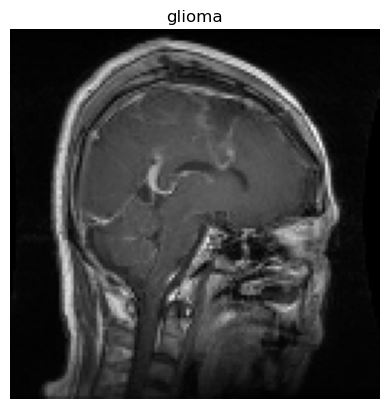

In [70]:
plt.imshow(X_train.iloc[1].values.reshape(128,128), cmap="gray")
plt.title(y_train.iloc[1])
plt.axis("off")
plt.show()

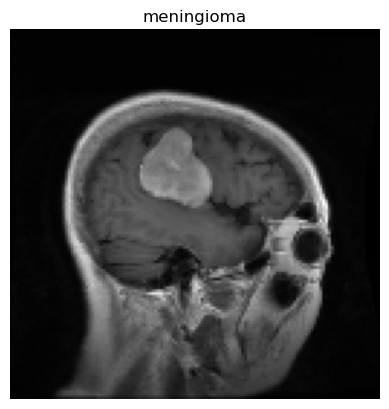

In [71]:
plt.imshow(X_train.iloc[1529].values.reshape(128,128), cmap="gray")
plt.title(y_train.iloc[1529])
plt.axis("off")
plt.show()

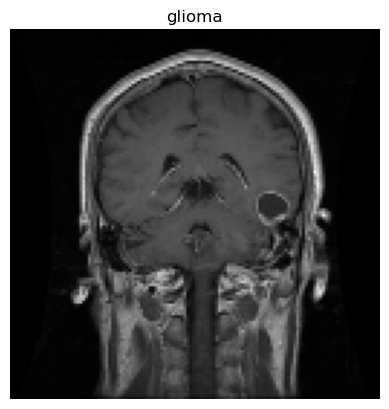

In [72]:
plt.imshow(X_train.iloc[499].values.reshape(128,128), cmap="gray")
plt.title(y_train.iloc[499])
plt.axis("off")
plt.show()

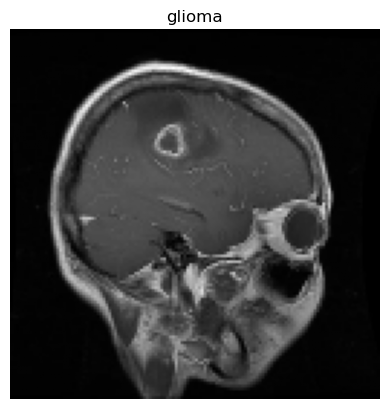

In [73]:
plt.imshow(X_train.iloc[923].values.reshape(128,128), cmap="gray")
plt.title(y_train.iloc[923])
plt.axis("off")
plt.show()

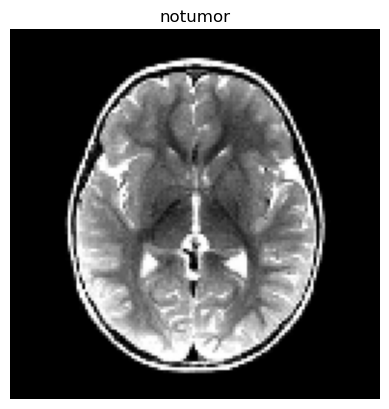

In [74]:
plt.imshow(X_train.iloc[3038].values.reshape(128,128), cmap="gray")
plt.title(y_train.iloc[3038])
plt.axis("off")
plt.show()

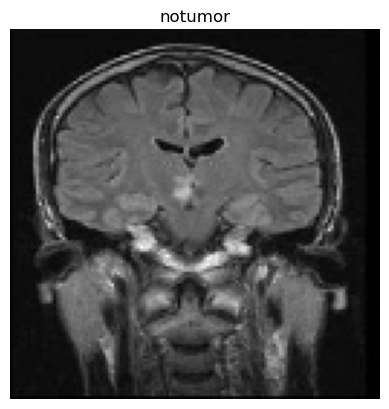

In [75]:
plt.imshow(X_train.iloc[3974].values.reshape(128,128), cmap="gray")
plt.title(y_train.iloc[3974])
plt.axis("off")
plt.show()

In [76]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [77]:
from sklearn.decomposition import PCA
pca=PCA(n_components=600)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [78]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)

In [79]:
from sklearn.svm import SVC

svm=SVC(kernel="rbf")

svm.fit(X_train_pca,y_train)

y_pred=svm.predict(X_test_pca)

In [80]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print("Accuracy score: ", accuracy_score(y_test,y_pred))

print("\nClassification Report: ")
print(classification_report(y_test,y_pred))

print("\nConfusion Matrix: ")
print(confusion_matrix(y_test,y_pred))

Accuracy score:  0.84

Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.69      0.75       400
           1       0.81      0.75      0.78       400
           2       0.83      0.97      0.90       400
           3       0.90      0.95      0.92       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.84      1600
weighted avg       0.84      0.84      0.84      1600


Confusion Matrix: 
[[275  57  52  16]
 [ 45 301  27  27]
 [  5   6 389   0]
 [ 13   8   0 379]]
